In [ ]:
#!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu


In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset



In [2]:
from google.colab import drive #Optional, comment out if on colab
drive.mount('/content/drive') 

Mounted at /content/drive


## checking the different emg patterns




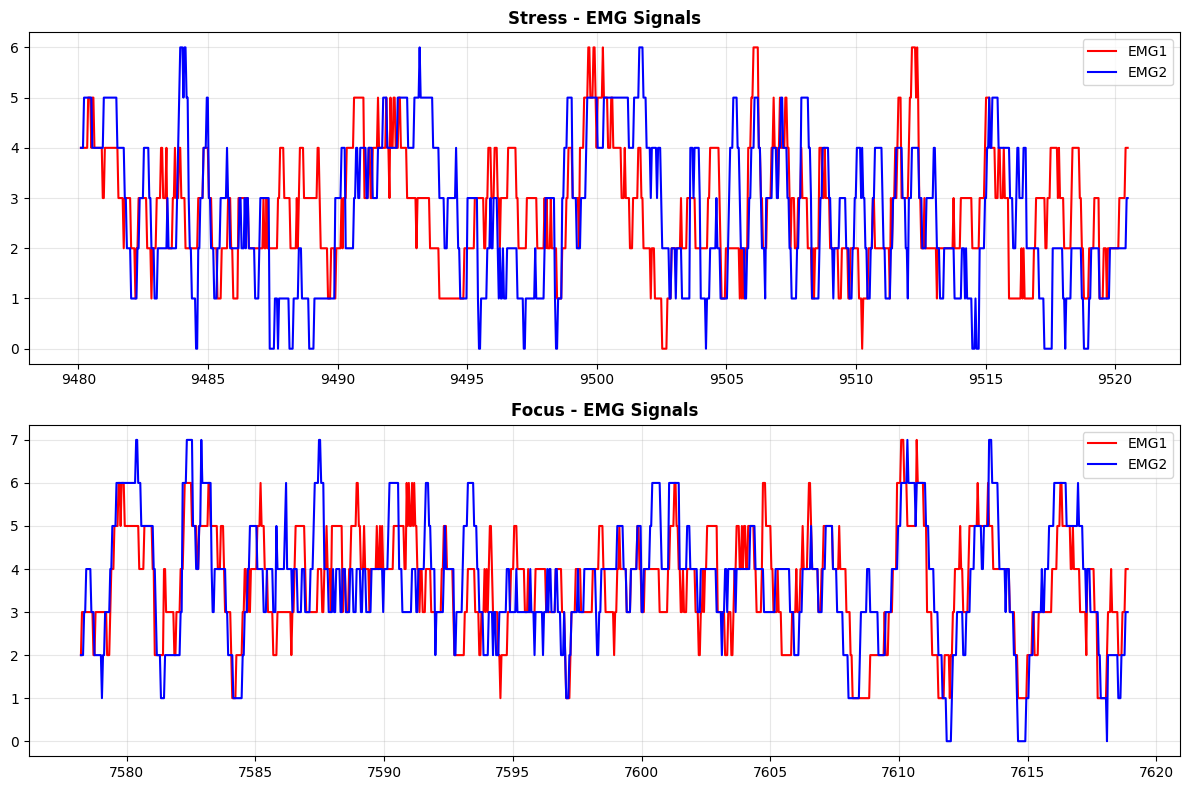

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Stress EMG
axes[0].plot(time_a[:1000], dfa['emg1'].values[:1000], 'r-', label='EMG1', linewidth=1.5)
axes[0].plot(time_a[:1000], dfa['emg2'].values[:1000], 'b-', label='EMG2', linewidth=1.5)
axes[0].set_title('Stress - EMG Signals', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Focus EMG
axes[1].plot(time_b[:1000], dfb['emg1'].values[:1000], 'r-', label='EMG1', linewidth=1.5)
axes[1].plot(time_b[:1000], dfb['emg2'].values[:1000], 'b-', label='EMG2', linewidth=1.5)
axes[1].set_title('Focus - EMG Signals', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Applying 16 4 for all the samples

In [3]:
import os, glob
import numpy as np
import pandas as pd

DATA_DIR = "/content/drive/MyDrive/EmoRecData" # Edit for your data directory

# Label mapping from filenames
label_map = {
    "baseline": "relaxed",
    "focus": "focused",
    "distract": "distracted",
    "stress": "stressed"
}

#all_cols = ['host_time_s', 't_ms', 'ax1', 'ay1', 'az1', 'roll1', 'pitch1', 'yaw1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'roll2', 'pitch2', 'yaw2', 'gx2', 'gy2', 'gz2', 'emg1', 'emg2'] # original


all_cols = ['host_time_s', 't_ms', 'ax1', 'ay1', 'az1', 'gx1', 'gy1', 'gz1', 'ax2', 'ay2', 'az2', 'gx2', 'gy2', 'gz2', 'emg1', 'emg2'] # without orientation data


time_cols = ["host_time_s", "t_ms"]
feature_cols = [c for c in all_cols if c not in time_cols]


WINDOW_SIZE = 125
STEP_SIZE = 32

print(f"Features: {len(feature_cols)}")
print(f"Window size: {WINDOW_SIZE}, Step: {STEP_SIZE}")

Features: 14
Window size: 125, Step: 32


In [4]:
def infer_label_from_filename(fname: str) -> str:
    lower = fname.lower()
    for key, lab in label_map.items():
        if key in lower:
            return lab
    raise ValueError(f"Could not infer label for: {fname}")


In [8]:
# Load + Window Data (IGNORES test files)
X_list = []
y_list = []

all_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print("Found files:", [os.path.basename(f) for f in all_files])

# IGNORE TEST FILES
ignore_files = [
    "focus_test.csv",
    "stress_w_20sec_baseline.csv",
    "adi_focused.csv",
    "louis_focused.csv",
    "louis_stressed.csv",
    "adi_stressed.csv", 'louis2_7_5min_stress.csv',"louis2_7_5min_focus.csv"]#,
    #"jun_5_7min_distract.csv",
    #"emmanuel_7_5min_baseline.csv",
    #"louis_7_5min_baseline.csv",
    #"louis_7_5min_baseline.csv"
#]

training_files = []
for fpath in all_files:
    fname = os.path.basename(fpath)

    # Skip exact matches
    if fname in ignore_files:
        print(f"⏭️  Skipping test file: {fname}")
        continue

    # Skip ANY file ending with "_backup"
    if fname.endswith("_backup.csv") or "_backup" in fname:
        print(f"⏭️  Skipping backup: {fname}")
        continue

    training_files.append(fpath)

print(f"\n✅ Using {len(training_files)} training files")
print(f"   (ignored {len(all_files) - len(training_files)} test/backup files)")

#training_files = [f for f in all_files if os.path.basename(f) not in ignore_files]
#print(f"\n Using {len(training_files)} training files (ignored {len(all_files)-len(training_files)} test files)")

for fpath in training_files:  # Changed from all_files
    fname = os.path.basename(fpath)
    print(f"Processing {fname}...")

    df = pd.read_csv(fpath)

    # Convert objects to numeric
    for col in feature_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    data = df[feature_cols].dropna().values  # raw features only for the windowing-processing pipeline

    label = infer_label_from_filename(fname)

    start = 0
    while start + WINDOW_SIZE <= len(data):
        window = data[start:start + WINDOW_SIZE]  # raw window (WINDOW_SIZE, n_features)

        # Per-window z-score normalization - EXACTLY like inference
        window_mean = np.mean(window, axis=0, keepdims=True)
        window_std  = np.std(window, axis=0, keepdims=True)
        window_norm = (window - window_mean) / (window_std + 1e-8)

        X_list.append(window_norm)
        y_list.append(label)
        start += STEP_SIZE

X = np.stack(X_list, axis=0)
y = np.array(y_list)

print(f"\n TRAINING Dataset: X{X.shape}, y{y.shape}")
print("Labels:", np.unique(y, return_counts=True))

# Printing global windows for hard coding it 

'''print("\n🔥 COMPUTING GLOBAL WINDOW STATISTICS FOR INFERENCE...")
global_mean = np.mean(X, axis=(0,1))  # Mean across all windows + all timesteps
global_std = np.std(X, axis=(0,1))    # Std across all windows + all timesteps

print(" COPY THESE VALUES INTO YOUR INFERENCE CODE:")
print("global_mean =", np.round(global_mean, 6).tolist())
print("global_std  =", np.round(global_std, 6).tolist())'''


Found files: ['jun_5_7min_focus.csv', 'jun_5_7min_stress.csv', 'jun_5_7min_distract.csv', 'jun_5_7min_baseline.csv', 'focus_test.csv', 'emmanuel_7_5min_baseline.csv', 'emmanuel_7_5min_focus.csv', 'louis_7_5min_distract.csv', 'louis_7_5min_focus.csv', 'louis_7_5min_stress.csv', 'louis_7_5min_baseline.csv', 'emmanuel_7_5min_stress.csv', 'adi1_7_5min_stress.csv', 'adi1_7_5min_focus.csv', 'adi1_7_5min_distract.csv', 'adi1_7_5min_baseline.csv', 'adi_7_5min_stress.csv', 'adi_7_5min_focus.csv', 'adi_7_5min_baseline.csv', 'adi_7_5min_distract.csv', 'emmanuel1_7_5min_stress.csv', 'emmanuel1_7_5min_baseline.csv', 'emmanuel1_7_5min_focus.csv', 'emmanuel1_7_5min_distract.csv', 'louis1_7_5min_baseline.csv', 'louis1_7_5min_stress.csv', 'louis1_7_5min_focus.csv', 'louis1_7_5min_distract.csv', 'emmanuel_7_5min_distract.csv', 'louis_stressed.csv', 'adi_focused.csv', 'louis_focused.csv', 'adi2_7_5min_focus.csv', 'adi2_7_5min_stress.csv', 'adi2_7_5min_distract.csv', 'adi2_7_5min_baseline.csv', 'emm2_7_5m

'print("\n🔥 COMPUTING GLOBAL WINDOW STATISTICS FOR INFERENCE...")\nglobal_mean = np.mean(X, axis=(0,1))  # Mean across all windows + all timesteps\nglobal_std = np.std(X, axis=(0,1))    # Std across all windows + all timesteps\n\nprint(" COPY THESE VALUES INTO YOUR INFERENCE CODE:")\nprint("global_mean =", np.round(global_mean, 6).tolist())\nprint("global_std  =", np.round(global_std, 6).tolist())'

In [9]:
label_encoder = LabelEncoder()
y_int = label_encoder.fit_transform(y)
print("Label mapping:", dict(zip(label_encoder.classes_, range(len(label_encoder.classes_)))))

y_cat = F.one_hot(torch.tensor(y_int)).numpy()

# Train val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y_int, test_size=0.2, random_state=42, stratify=y_int
)

print(f"\nTrain: {X_train.shape[0]} samples")
print(f"Val:   {X_val.shape[0]} samples")

Label mapping: {np.str_('distracted'): 0, np.str_('focused'): 1, np.str_('relaxed'): 2, np.str_('stressed'): 3}

Train: 8505 samples
Val:   2127 samples


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

X_train_torch = torch.FloatTensor(X_train).transpose(1, 2) 
X_val_torch   = torch.FloatTensor(X_val).transpose(1, 2)
y_train_torch = torch.LongTensor(y_train)
y_val_torch   = torch.LongTensor(y_val)

print(f"X_train_torch shape: {X_train_torch.shape}")
print(f"X_val_torch shape:   {X_val_torch.shape}")

BATCH_SIZE = 64
train_dataset = TensorDataset(X_train_torch, y_train_torch)
val_dataset   = TensorDataset(X_val_torch,   y_val_torch)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

for batch_X, batch_y in train_loader:
    print(f"FIRST BATCH shape: {batch_X.shape}")
    break

Using device: cuda
X_train_torch shape: torch.Size([8505, 14, 125])
X_val_torch shape:   torch.Size([2127, 14, 125])
FIRST BATCH shape: torch.Size([64, 14, 125])


In [11]:
# Train REGULARIZED version
class EmotionCNN_Reg(nn.Module):
    def __init__(self, input_channels=14, num_classes=4):
        super().__init__()
        self.conv1 = nn.Conv1d(input_channels, 16, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm1d(16)
        self.pool1 = nn.MaxPool1d(2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)

        #self.fc1       = nn.Linear(32 * 4, 64) # use for window size =16 / step size 4
        self.fc1       = nn.Linear(32 * 31, 64)
        self.dropout1  = nn.Dropout(0.3)
        self.fc2       = nn.Linear(64, 32)
        self.dropout2  = nn.Dropout(0.5)
        self.fc3       = nn.Linear(32, num_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)
        x = F.dropout(x, 0.2)

        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x

# Retrain with regularization
model_reg = EmotionCNN_Reg(input_channels=X_train_torch.shape[1],
                           num_classes=4).to(device)
optimizer_reg = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)
criterion = nn.CrossEntropyLoss()

print("🛡️ Training regularized model...")
print("Input channels:", X_train_torch.shape[1])
print("Total params:", sum(p.numel() for p in model_reg.parameters()))


🛡️ Training regularized model...
Input channels: 14
Total params: 68116


In [16]:
# Use REGULARIZED model
model_reg = EmotionCNN_Reg(
    input_channels=len(feature_cols), 
    num_classes=len(label_encoder.classes_)   
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_reg.parameters(), lr=0.001, weight_decay=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

EPOCHS = 150
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0

print("🛡️ Training REGULARIZED model...")
print(f"Input channels: {len(feature_cols)}")
print(f"Total params: {sum(p.numel() for p in model_reg.parameters()):,}")

for epoch in range(EPOCHS):
    # Training
    model_reg.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()
        outputs = model_reg(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += batch_y.size(0)
        correct_train += (predicted == batch_y).sum().item()

    # Validation
    model_reg.eval()
    val_loss = 0.0
    correct_val, total_val = 0, 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model_reg(batch_X)
            loss = criterion(outputs, batch_y)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_val += batch_y.size(0)
            correct_val += (predicted == batch_y).sum().item()

    # Metrics
    train_loss = running_loss / len(train_loader)
    val_loss_epoch = val_loss / len(val_loader)
    train_acc = 100 * correct_train / total_train
    val_acc = 100 * correct_val / total_val

    train_losses.append(train_loss)
    val_losses.append(val_loss_epoch)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    scheduler.step(val_loss_epoch)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_reg.state_dict(), "best_emotion_cnn_reg_1.pth")

    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        print(
            f"Epoch {epoch+1}/{EPOCHS}: "
            f"Train: {train_loss:.4f} ({train_acc:.1f}%) | "
            f"Val: {val_loss_epoch:.4f} ({val_acc:.1f}%)"
        )

print(f"\n✅ Best val accuracy: {best_val_acc:.1f}%")
print("💾 Saved: best_emotion_cnn_reg.pth")


🛡️ Training REGULARIZED model...
Input channels: 14
Total params: 68,116
Epoch 1/150: Train: 1.3822 (26.7%) | Val: 1.3033 (37.0%)
Epoch 11/150: Train: 0.7508 (63.8%) | Val: 0.6902 (66.0%)
Epoch 21/150: Train: 0.5696 (73.5%) | Val: 0.5665 (72.2%)
Epoch 31/150: Train: 0.4832 (80.1%) | Val: 0.5631 (77.0%)
Epoch 41/150: Train: 0.3898 (85.4%) | Val: 0.4267 (83.4%)
Epoch 51/150: Train: 0.3367 (87.9%) | Val: 0.3703 (86.5%)
Epoch 61/150: Train: 0.2968 (89.6%) | Val: 0.3644 (86.8%)
Epoch 71/150: Train: 0.2838 (90.5%) | Val: 0.3318 (87.9%)
Epoch 81/150: Train: 0.2648 (91.4%) | Val: 0.3386 (87.9%)
Epoch 91/150: Train: 0.2669 (91.0%) | Val: 0.3550 (86.8%)
Epoch 101/150: Train: 0.2472 (91.8%) | Val: 0.3345 (87.8%)
Epoch 111/150: Train: 0.2447 (91.7%) | Val: 0.3422 (87.9%)
Epoch 121/150: Train: 0.2510 (91.7%) | Val: 0.3462 (88.1%)
Epoch 131/150: Train: 0.2620 (91.1%) | Val: 0.3550 (87.0%)
Epoch 141/150: Train: 0.2482 (91.8%) | Val: 0.3578 (87.4%)
Epoch 150/150: Train: 0.2641 (91.0%) | Val: 0.3531 (8

In [17]:
from google.colab import files # Comment out if not on colab.
files.download("best_emotion_cnn_reg_1.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
# Loading BEST regularized model
model_reg.load_state_dict(torch.load('best_emotion_cnn_reg_1.pth'))
model_reg.eval()

# Get predictions
all_preds_reg = []
all_labels_reg = []

with torch.no_grad():
    for batch_X, batch_y in val_loader:
        batch_X = batch_X.to(device)
        outputs = model_reg(batch_X)
        _, predicted = torch.max(outputs, 1)
        all_preds_reg.extend(predicted.cpu().numpy())
        all_labels_reg.extend(batch_y.cpu().numpy())

print("REGULARIZED MODEL RESULTS:")
print(classification_report(all_labels_reg, all_preds_reg,
                          target_names=label_encoder.classes_))


📊 REGULARIZED MODEL RESULTS:
              precision    recall  f1-score   support

  distracted       0.85      0.84      0.84       538
     focused       0.90      0.92      0.91       533
     relaxed       0.93      0.92      0.93       516
    stressed       0.83      0.83      0.83       540

    accuracy                           0.88      2127
   macro avg       0.88      0.88      0.88      2127
weighted avg       0.88      0.88      0.88      2127



<Figure size 1000x800 with 0 Axes>

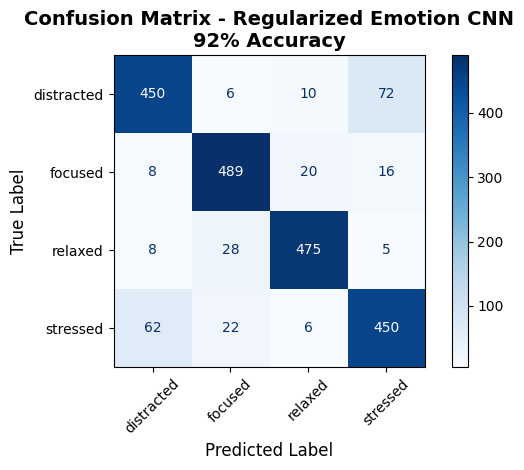

Confusion Matrix (True ↓ | Predicted →):
[[450   6  10  72]
 [  8 489  20  16]
 [  8  28 475   5]
 [ 62  22   6 450]]

Class order: ['distracted' 'focused' 'relaxed' 'stressed']


In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels_reg, all_preds_reg)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                             display_labels=label_encoder.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix - Regularized Emotion CNN\n92% Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

print("Confusion Matrix (True ↓ | Predicted →):")
print(cm)
print(f"\nClass order: {label_encoder.classes_}")


In [20]:
# Prediction function for the previous pre-processing pipeline

'''def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Normalize features (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs'''

def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Convert objects to numeric (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    data = df[feature_cols].dropna().values 

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        window = data[start:start + WINDOW_SIZE] 

        window_mean = np.mean(window, axis=0, keepdims=True)
        window_std  = np.std(window, axis=0, keepdims=True)
        window_norm = (window - window_mean) / (window_std + 1e-8)

        windows.append(window_norm)
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)  # (n_windows, 125, 14)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)  

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs

test_file = "/content/drive/MyDrive/EmoRecData/louis_stressed.csv" # change path

labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\nPREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f" TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on louis_stressed.csv:
🎯 21 windows predicted
Most common counts: [ 0  0  0 21]

First 10 predictions:
   1: stressed
   2: stressed
   3: stressed
   4: stressed
   5: stressed
   6: stressed
   7: stressed
   8: stressed
   9: stressed
  10: stressed

📊 PREDICTION DISTRIBUTION:
  stressed  : 21/21 (100%)

🎯 TOP PREDICTION: stressed (100%)
📋 TRUE LABEL:     stressed


In [21]:
test_file = "/content/drive/MyDrive/EmoRecData/adi_focused.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

# Fixed output display
filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n📊 PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f" TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on adi_focused.csv:
🎯 8 windows predicted
Most common counts: [0 2 0 6]

First 10 predictions:
   1: stressed
   2: stressed
   3: stressed
   4: stressed
   5: stressed
   6: focused
   7: focused
   8: stressed

📊 PREDICTION DISTRIBUTION:
  focused   : 2/8 (25%)
  stressed  : 6/8 (75%)

🎯 TOP PREDICTION: stressed (75%)
📋 TRUE LABEL:     focused


In [22]:
test_file = "/content/drive/MyDrive/EmoRecData/louis_focused.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

filename = os.path.basename(test_file)
print(f"🛡️ REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"🎯 {len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n🎯 TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f" TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on louis_focused.csv:
🎯 20 windows predicted
Most common counts: [ 0 11  0  9]

First 10 predictions:
   1: focused
   2: focused
   3: focused
   4: stressed
   5: focused
   6: stressed
   7: stressed
   8: focused
   9: stressed
  10: stressed

📊 PREDICTION DISTRIBUTION:
  focused   : 11/20 (55%)
  stressed  : 9/20 (45%)

🎯 TOP PREDICTION: focused (55%)
📋 TRUE LABEL:     focused


In [ ]:
feature_cols = [
    "ax1", "ay1", "az1",
    "gx1", "gy1", "gz1",
    "ax2", "ay2", "az2",
    "gx2", "gy2", "gz2", "emg1", "emg2"
]


'''def predict_file_reg(fpath: str, model_reg, label_encoder):
    """Predict emotions on new file using regularized model."""
    df = pd.read_csv(fpath)

    # Normalize features (same as training)
    for col in feature_cols:
        if col in df.columns:
            df[f"{col}_norm"] = (df[col] - df[col].mean()) / df[col].std()

    norm_feature_cols = [f"{col}_norm" for col in feature_cols]
    data = df[norm_feature_cols].dropna().values

    windows = []
    start = 0
    while start + WINDOW_SIZE <= len(data):
        windows.append(data[start:start + WINDOW_SIZE])
        start += STEP_SIZE

    if not windows:
        return None, None

    X_new = np.stack(windows)
    X_new_torch = torch.FloatTensor(X_new).transpose(1, 2).to(device)

    model_reg.eval()
    with torch.no_grad():
        outputs = model_reg(X_new_torch)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = np.argmax(probs, axis=1)

    labels = label_encoder.inverse_transform(preds)
    return labels, probs'''

# HAVE TO FORCE NUMERIC FOR THIS FILE ALONE



test_file = "/content/drive/MyDrive/EmoRecData/focus_test.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

filename = os.path.basename(test_file)
print(f"REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"{len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\nPREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f"TRUE LABEL:     {true_label}")


🛡️ REGULARIZED MODEL (92% val acc) on focus_test.csv:
🎯 6 windows predicted
Most common counts: [0 5 1 0]

First 10 predictions:
   1: relaxed
   2: focused
   3: focused
   4: focused
   5: focused
   6: focused

📊 PREDICTION DISTRIBUTION:
  focused   : 5/6 (83%)
  relaxed   : 1/6 (17%)

🎯 TOP PREDICTION: focused (83%)
📋 TRUE LABEL:     focused


In [27]:
test_file = "/content/drive/MyDrive/EmoRecData/louis3_7_5min_distract.csv"
labels_reg, probs_reg = predict_file_reg(test_file, model_reg, label_encoder)

filename = os.path.basename(test_file)
print(f" REGULARIZED MODEL (92% val acc) on {filename}:")
print(f"{len(labels_reg)} windows predicted")
print(f"Most common counts: {np.bincount([label_encoder.transform([l])[0] for l in labels_reg], minlength=4)}")

print("\nFirst 10 predictions:")
for i, pred in enumerate(labels_reg[:10]):
    print(f"  {i+1:2d}: {pred}")

print("\n PREDICTION DISTRIBUTION:")
unique, counts = np.unique(labels_reg, return_counts=True)
total_windows = len(labels_reg)
for label, count in zip(unique, counts):
    pct = count / total_windows * 100
    print(f"  {label:10s}: {count}/{total_windows} ({pct:.0f}%)")

# Top prediction
top_class_idx = np.argmax(np.bincount([label_encoder.transform([l])[0] for l in labels_reg]))
top_class = label_encoder.classes_[top_class_idx]
top_pct = 100 * np.max(np.bincount([label_encoder.transform([l])[0] for l in labels_reg])) / len(labels_reg)
true_label = infer_label_from_filename(filename)
print(f"\n TOP PREDICTION: {top_class} ({top_pct:.0f}%)")
print(f" TRUE LABEL:     {true_label}")

🛡️ REGULARIZED MODEL (92% val acc) on louis3_7_5min_distract.csv:
🎯 353 windows predicted
Most common counts: [151  12  88 102]

First 10 predictions:
   1: distracted
   2: distracted
   3: distracted
   4: distracted
   5: relaxed
   6: relaxed
   7: distracted
   8: stressed
   9: distracted
  10: stressed

📊 PREDICTION DISTRIBUTION:
  distracted: 151/353 (43%)
  focused   : 12/353 (3%)
  relaxed   : 88/353 (25%)
  stressed  : 102/353 (29%)

🎯 TOP PREDICTION: distracted (43%)
📋 TRUE LABEL:     distracted
